# Brite Hackathon — Dirty Data, Real Decisions

## Problem Understanding

The organization has observed that case closure times have changed,
but the reason for this change is unclear.

The only available evidence is a historical case-management system
export covering 2023–2025.

The objective of this analysis is to:

1. Assess the quality and reliability of the available data.
2. Determine whether case closure times increased between 2023 and 2025.
3. Identify the operational factors associated with changes in closure time.
4. Determine whether the available data can establish the effect of
   the 2024 high-priority triage process.
5. Clearly identify any question that the data cannot reliably answer.

The analysis will prioritize transparency, reproducibility and
documented cleaning decisions.

## Operational Questions

### Question 1
Have case closure times increased between 2023 and 2025, and if so, by how much?

### Question 2
If closure times have changed, what is driving the change?

### Question 3
Did the case triage process introduced during 2024 reduce closure times
for high-priority cases?

## Dataset

The analysis uses the supplied case-management export covering 2023–2025.

The raw dataset is preserved unchanged. All transformations and exclusions
will be performed on derived copies so that the original data remains
available for auditing.

In [163]:
import pandas as pd
import numpy as np

In [164]:
df = pd.read_csv("/content/case-export-2023-2025.csv")

print("CSV loaded successfully!")

CSV loaded successfully!


In [165]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 15100
Number of columns: 10


In [166]:
print(df.columns.tolist())

['case_id', 'client_ref', 'district', 'intake_date', 'closure_date', 'status', 'category', 'priority', 'caseworker_id', 'contact_count']


In [167]:
df.head(10)

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count
0,CC-2023-21985,Stephanie Grady,Ash Hill,2023-04-20,2023-07-17,Closed,appeals,NaN,W194,4
1,CC-2023-10494,Timothy Alvarez,Weybridge,2023-04-14,2023-05-04,Closed,Standard,NaN,W185,2
2,CC-2024-19806,Patricia Danvers,Northgate,2024-05-10,2024-05-19,Closed,Expedited,Medium,W184,1
3,CC-2023-10907,Kenneth Delgado,Weybridge,"March 29, 2023","May 18, 2023",Closed,appeal,NaN,W201,4
4,CC-2024-23300,Ashley Zamora,Calder Central,"April 24, 2024","July 1, 2024",Closed,Complex,Medium,W219,4
5,CC-2025-13518,Richard Okonkwo,Calder Central,2025-12-28,NaN,Open,std,High,W109,2
6,CC-2023-21904,Richard Rasmussen,Ash Hill,02/09/2023,03/04/2023,Closed,Standard,NaN,W212,3
7,CC-2023-17025,Betty Quill,Calder Central,2023-06-30,2023-07-10,Closed,Expedited,NaN,W175,2
8,CC-2025-14946,Sandra Grady,Northgate,2025-03-25,2025-04-20,Closed,Standard,Medium,W245,6
9,CC-2024-17144,Jeffrey Okonkwo,Calder Central,"September 18, 2024","February 16, 2025",Closed,Complex,Low,W124,1


In [168]:
df.tail(10)

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count
15090,CC-2024-23593,Timothy Sedgwick,Calder Central,02/20/2024,07/01/2024,Closed,Standard,NaN,W169,5
15091,CC-2023-13684,Betty Ellery,Calder Central,2023-02-08,2023-03-24,Closed,Review,NaN,W167,3
15092,CC-2023-21049,David Hollis,Calder Central,04/20/2023,05/22/2023,Closed,Appeal,NaN,W106,4
15093,CC-2025-21168,Amanda Kessler,Calder Central,2025-03-04,2025-05-12,Closed,Standard,Low,W257,1
15094,CC-2025-11640,Betty Eastwood,Northgate,2025-12-07,NaN,Open,complex,Low,W198,5
15095,CC-2025-22292,Michael Fowler,Northgate,"February 16, 2025","March 2, 2025",Closed,Standard case,High,W183,1
15096,CC-2023-11711,Jessica Yeardley,Northgate,2023-04-10,2023-05-14,Closed,Standard,NaN,W176,3
15097,CC-2025-11647,Richard Pemberton,Ash Hill,05/14/2025,06/06/2025,Closed,std,High,W218,0
15098,CC-2024-15396,Emily Thorne,Calder Central,2024-03-02,2024-04-01,Closed,Appeal,Low,W118,7
15099,CC-2025-13166,Sandra Ellery,Northgate,07/25/2025,08/11/2025,Closed,routine,High,W229,5


In [169]:
raw_df = df.copy()

In [170]:
clean_df = raw_df.copy()

In [171]:
df.shape

(15100, 10)

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15100 entries, 0 to 15099
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   case_id        15100 non-null  object
 1   client_ref     15100 non-null  object
 2   district       15100 non-null  object
 3   intake_date    15100 non-null  object
 4   closure_date   14304 non-null  object
 5   status         15100 non-null  object
 6   category       15100 non-null  object
 7   priority       9244 non-null   object
 8   caseworker_id  15100 non-null  object
 9   contact_count  15100 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 1.2+ MB


In [173]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,15100,14916,CC-2025-23024,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_ref,15100,1745,Jessica Ashford,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,15100,4,Calder Central,5195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intake_date,15100,3135,2024-09-30,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
closure_date,14304,3084,2024-07-01,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,15100,2,Closed,14304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,15100,40,Standard,5132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,9244,3,Low,4103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
caseworker_id,15100,161,W166,123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact_count,15100.0,NaN,NaN,NaN,3.552053,2.122328,0.0,2.0,3.0,5.0,12.0


In [174]:
df.sample(5, random_state=42)

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count
14845,CC-2024-19620,Maria Bennett,Northgate,11/12/2024,07/01/2024,Closed,normal,Medium,W147,4
14120,CC-2025-23666,Karen Fowler,Weybridge,11/03/2025,NaN,Open,STANDARD,Low,W206,7
14860,cc-2025-10698,Brian Nakamura,Calder Central,"September 22, 2025","December 18, 2025",Closed,Complex,Low,W203,3
884,CC-2023-15358,Nancy Yeardley,Northgate,2023-08-06,2023-08-29,Closed,Expedited - urgent,NaN,W205,1
411,CC-2023-17771,Stephanie Vance,Northgate,2023-01-27,2023-01-31,Closed,Expedited,NaN,W167,5


## 3.1 Data Dictionary

| Column | Description | Role in Analysis |
|---|---|---|
| `case_id` | Unique identifier for a case | Identifying and detecting duplicate cases |
| `client_ref` | Reference associated with the client | Supporting record identification |
| `district` | District associated with the case | Used to investigate geographical differences |
| `intake_date` | Date when the case was received | Used to calculate closure duration and yearly trends |
| `closure_date` | Date when the case was closed | Used to calculate closure duration |
| `status` | Current status of the case | Used to distinguish open and closed cases |
| `category` | Category/type of the case | Used to investigate operational drivers |
| `priority` | Priority assigned to the case | Used particularly for high-priority analysis |
| `caseworker_id` | Identifier of the assigned caseworker | Used to investigate possible caseworker-level patterns |
| `contact_count` | Number of recorded contacts for the case | Used as a potential operational indicator |

## 3.2 Mapping Data Fields to Operational Questions

| Operational Question | Important Fields | Why They Are Needed |
|---|---|---|
| Q1 — Have closure times increased between 2023 and 2025? | `intake_date`, `closure_date`, `status` | Intake and closure dates are required to calculate closure time; status helps distinguish completed and open cases |
| Q2 — What is driving the change in closure times? | `district`, `category`, `priority`, `caseworker_id`, `intake_date`, `closure_date` | These fields allow closure-time changes to be compared across operational groups |
| Q3 — Did the 2024 triage process reduce closure times for high-priority cases? | `priority`, `intake_date`, `closure_date`, `status` | These fields allow descriptive comparison of high-priority closure times |

In [175]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (15100, 10)

Column Names:
['case_id', 'client_ref', 'district', 'intake_date', 'closure_date', 'status', 'category', 'priority', 'caseworker_id', 'contact_count']

Data Types:
case_id          object
client_ref       object
district         object
intake_date      object
closure_date     object
status           object
category         object
priority         object
caseworker_id    object
contact_count     int64
dtype: object


In [176]:
missing_report = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_report.sort_values("Missing Count", ascending=False)

,Missing Count,Missing %
priority,5856,38.78
closure_date,796,5.27
client_ref,0,0.00
case_id,0,0.00
intake_date,0,0.00
district,0,0.00
status,0,0.00
category,0,0.00
caseworker_id,0,0.00
contact_count,0,0.00


In [177]:
print("Missing priority:", df["priority"].isna().sum())
print("Missing closure date:", df["closure_date"].isna().sum())

Missing priority: 5856
Missing closure date: 796


In [178]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 28


In [179]:
print("Duplicate case IDs:",
      df["case_id"].duplicated().sum())

Duplicate case IDs: 184


In [180]:
df["case_id_normalized"] = (
    df["case_id"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)

In [181]:
duplicate_normalized = df[
    df["case_id_normalized"].duplicated(keep=False)
].sort_values("case_id_normalized")

duplicate_normalized

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count,case_id_normalized
12138,CC-2023-10091,Emily Bennett,Ash Hill,2023-08-17,2023-09-05,Closed,Standard,NaN,W157,4,CC202310091
9572,cc-2023-10091,Emily Bennett,Ash Hill,08/17/2023,09/05/2023,Closed,Standard,NaN,W157,3,CC202310091
1193,CC-2023-10109,Jessica Hollis,Calder Central,09/05/2023,10/12/2023,Closed,Standard,NaN,W151,2,CC202310109
5155,CC-2023-10109,Jessica Hollis,Calder Central,2023-09-05,2023-10-12,Closed,Standard,NaN,W151,2,CC202310109
11539,CC-2023-10173,Paul Fowler,Ash Hill,"February 16, 2023","April 19, 2023",Closed,Complex,NaN,W238,0,CC202310173
...,...,...,...,...,...,...,...,...,...,...,...
7091,CC-2025-24003,Andrew Okonkwo,Calder Central,"October 7, 2025",NaN,Open,Complex,Low,W136,7,CC202524003
343,CC 2025 24055,JESSICA LINDQUIST,Weybridge,2025-05-12,2025-08-31,Closed,Standard,Low,W194,3,CC202524055
13983,CC-2025-24055,Jessica Lindquist,Weybridge,2025-05-12,2025-08-31,Closed,Standard,Low,W194,3,CC202524055
14725,cc-2025-24090,STEPHANIE PEMBERTON,Northgate,2025-03-14,2025-04-23,Closed,Standard,Low,W196,6,CC202524090


In [182]:
print(df["intake_date"].head(20).tolist())
print(df["closure_date"].dropna().head(20).tolist())

['2023-04-20', '2023-04-14', '2024-05-10', 'March 29, 2023', 'April 24, 2024', '2025-12-28', '02/09/2023', '2023-06-30', '2025-03-25', 'September 18, 2024', '2025-10-27', '02/20/2023', '2025-07-11', '08/14/2024', 'March 30, 2025', 'September 30, 2023', '2023-02-16', '2023-02-22', '2023-04-10', '05/31/2024']
['2023-07-17', '2023-05-04', '2024-05-19', 'May 18, 2023', 'July 1, 2024', '03/04/2023', '2023-07-10', '2025-04-20', 'February 16, 2025', '2025-11-08', '03/04/2023', '2025-09-10', '07/01/2024', 'May 10, 2025', 'November 14, 2023', '2023-03-03', '2023-03-14', '2023-05-09', '07/23/2024', '02/11/2024']


In [183]:
intake_test = pd.to_datetime(
    df["intake_date"],
    format="mixed",
    errors="coerce"
)

closure_test = pd.to_datetime(
    df["closure_date"],
    format="mixed",
    errors="coerce"
)

In [184]:
bad_intake = df[
    df["intake_date"].notna() &
    intake_test.isna()
]

bad_closure = df[
    df["closure_date"].notna() &
    closure_test.isna()
]

print("Unparseable intake dates:", len(bad_intake))
print("Unparseable closure dates:", len(bad_closure))

Unparseable intake dates: 0
Unparseable closure dates: 0


In [185]:

print("Earliest intake date:", intake_test.min())
print("Latest intake date:", intake_test.max())

print("Earliest closure date:", closure_test.min())
print("Latest closure date:", closure_test.max())

today = pd.Timestamp.today().normalize()

future_intake = df[
    intake_test > today
]

future_closure = df[
    closure_test > today
]

print("\nFuture intake dates:", len(future_intake))
print("Future closure dates:", len(future_closure))

Earliest intake date: 2023-01-01 00:00:00
Latest intake date: 2025-12-31 00:00:00
Earliest closure date: 2021-12-08 00:00:00
Latest closure date: 2025-12-31 00:00:00

Future intake dates: 0
Future closure dates: 0


In [186]:
clean_df["contact_count"].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,contact_count
count,15100.000000
mean,3.552053
std,2.122328
min,0.000000
1%,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
95%,7.000000
99%,9.000000


In [187]:
Q1 = clean_df["contact_count"].quantile(0.25)
Q3 = clean_df["contact_count"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

contact_outliers = clean_df[
    clean_df["contact_count"] > upper_limit
]

print("Potential contact-count outliers:",
      len(contact_outliers))

Potential contact-count outliers: 57


In [188]:
for col in ["district", "category", "priority", "status"]:
    print(f"\n--- {col} ---")
    print(clean_df[col].astype("string").value_counts(dropna=False).head(30))


--- district ---
district
Calder Central    5195
Northgate         3937
Weybridge         3592
Ash Hill          2376
Name: count, dtype: Int64

--- category ---
category
Standard                  5132
Complex                   2233
Expedited                 1241
Review                    1100
Appeal                     870
routine                    316
standard - no issues       288
normal                     282
Standard case              269
std                        267
Std.                       265
standard                   262
STANDARD                   257
complex case               138
COMPLEX                    133
multi-agency               129
complicated                119
cmplx                      119
Complex (referred)         104
Complex - multi agency     104
complex                     97
review                      89
12 month review             83
Annual review               83
rev                         83
exp                         79
rush                  

In [189]:
for col in ["district", "category", "priority", "status"]:
    clean_df[col + "_clean"] = (
        clean_df[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

In [190]:
print(clean_df["district"].value_counts(dropna=False))

district
Calder Central    5195
Northgate         3937
Weybridge         3592
Ash Hill          2376
Name: count, dtype: int64


In [191]:
clean_df["case_id_normalized"] = (
    clean_df["case_id"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)

In [192]:
print(clean_df[["case_id", "case_id_normalized"]].head())

         case_id case_id_normalized
0  CC-2023-21985        CC202321985
1  CC-2023-10494        CC202310494
2  CC-2024-19806        CC202419806
3  CC-2023-10907        CC202310907
4  CC-2024-23300        CC202423300


In [193]:
print(
    "Duplicate normalized case IDs:",
    clean_df["case_id_normalized"].duplicated().sum()
)

Duplicate normalized case IDs: 900


In [194]:
clean_df = clean_df.drop_duplicates(
    subset="case_id_normalized",
    keep="first"
)

In [195]:
duplicate_cases[
    [
        "case_id",
        "client_ref",
        "intake_date",
        "closure_date",
        "status",
        "category",
        "priority",
        "caseworker_id",
        "contact_count"
    ]
].sort_values("case_id")

,case_id,client_ref,intake_date,closure_date,status,category,priority,caseworker_id,contact_count
2763,CC-2023-10257,Melissa Lindquist,2023-02-11,2023-03-17,Closed,Standard,NaN,W259,6
9263,CC-2023-10628,Betty Crowley,2023-03-08,2023-05-04,Closed,Standard,NaN,W201,3
12982,CC-2023-11048,David Fowler,2023-10-24,2024-07-01,Closed,Standard,NaN,W128,5
5965,CC-2023-11124,BRIAN QUILL,2023-03-30,2023-04-25,Closed,Standard,NaN,W190,3
6570,CC-2023-11438,SARAH WHITLOCK,2023-07-25,2023-08-07,Closed,Expedited,NaN,W123,7
...,...,...,...,...,...,...,...,...,...
1855,cc-2025-22907,TIMOTHY JARRETT,10/09/2025,11/03/2025,Closed,standard,Low,W128,1
2329,cc-2025-22985,Stephanie Bennett,2025-09-05,2025-11-05,Closed,standard,Medium,W183,1
4610,cc-2025-23414,Kimberly Nakamura,"July 29, 2025",NaN,Open,Complex,Low,W250,1
11295,cc-2025-23522,Carol Ellery,01/23/2025,05/07/2025,Closed,routine,Medium,W246,4


In [196]:
analysis_df["closure_days"].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
)

,closure_days
count,12903.000000
mean,51.096412
std,56.245254
min,0.000000
1%,6.000000
5%,11.000000
50%,36.000000
95%,130.000000
99%,334.980000
max,546.000000


In [197]:
q1_sensitivity = (
    analysis_df
    .groupby("intake_year")["closure_days"]
    .agg(
        cases="count",
        median_days="median",
        mean_days="mean"
    )
    .reset_index()
)

q1_sensitivity

,intake_year,cases,median_days,mean_days
0,2023,4636,34.0,55.465272
1,2024,4535,37.0,48.315987
2,2025,3732,38.0,49.047964


In [198]:
date_check = pd.DataFrame({
    "intake": intake_test,
    "closure": closure_test
})

date_check["closure_days"] = (
    date_check["closure"] - date_check["intake"]
).dt.days

In [199]:
negative_dates = date_check[
    date_check["closure_days"] < 0
]

print("Negative closure durations:",
      len(negative_dates))

Negative closure durations: 573


In [200]:
print(
    pd.crosstab(
        df["status"],
        df["closure_date"].isna(),
        margins=True
    )
)

closure_date  False  True    All
status                          
Closed        14304     0  14304
Open              0   796    796
All           14304   796  15100


In [201]:
open_with_closure = df[
    (df["status"] == "Open") &
    (df["closure_date"].notna())
]

closed_without_closure = df[
    (df["status"] == "Closed") &
    (df["closure_date"].isna())
]

print("Open with closure date:", len(open_with_closure))
print("Closed without closure date:", len(closed_without_closure))

Open with closure date: 0
Closed without closure date: 0


In [202]:
print("Number of unique categories:",
      df["category"].nunique())

print(df["category"].value_counts(dropna=False))

Number of unique categories: 40
category
Standard                  5132
Complex                   2233
Expedited                 1241
Review                    1100
Appeal                     870
routine                    316
standard - no issues       288
normal                     282
Standard case              269
std                        267
Std.                       265
standard                   262
STANDARD                   257
complex case               138
COMPLEX                    133
multi-agency               129
complicated                119
cmplx                      119
Complex (referred)         104
Complex - multi agency     104
complex                     97
review                      89
12 month review             83
Annual review               83
rev                         83
exp                         79
rush                        78
expedited                   76
periodic review             74
appeals                     73
fast track                  7

In [203]:
print(df["priority"].value_counts(dropna=False))

priority
NaN       5856
Low       4103
Medium    3754
High      1387
Name: count, dtype: int64


In [204]:
pd.crosstab(
    df["priority"],
    df["status"],
    dropna=False
)

status,Closed,Open
priority,,
High,1276,111
Low,3741,362
Medium,3431,323
NaN,5856,0


In [205]:
df["intake_year_test"] = intake_test.dt.year

pd.crosstab(
    df["intake_year_test"],
    df["priority"],
    dropna=False
)

priority,High,Low,Medium,NaN
intake_year_test,,,,
2023,0,0,0,5048
2024,632,1868,1727,808
2025,755,2235,2027,0


In [206]:
df["closure_date"].value_counts().head(20)

,count
closure_date,
2024-07-01,347
07/01/2024,192
"July 1, 2024",111
2023-05-25,17
2025-07-14,16
2025-06-23,16
2024-04-08,15
2025-08-09,15
2025-02-11,15


In [207]:
df["category"].value_counts().head(20)

,count
category,
Standard,5132
Complex,2233
Expedited,1241
Review,1100
Appeal,870
routine,316
standard - no issues,288
normal,282
Standard case,269


In [208]:
df["district"].value_counts()
df["status"].value_counts()
df["priority"].value_counts(dropna=False)

,count
priority,
NaN,5856
Low,4103
Medium,3754
High,1387


In [209]:
df["contact_count"].describe()

,contact_count
count,15100.000000
mean,3.552053
std,2.122328
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,12.000000


In [210]:
print("Zero contact cases:",
      (df["contact_count"] == 0).sum())

print("Negative contact cases:",
      (df["contact_count"] < 0).sum())

Zero contact cases: 1258
Negative contact cases: 0


In [211]:
quality_assessment = pd.DataFrame([
    ["Missing values", "priority",
     df["priority"].isna().sum(),
     "High",
     "Limits high-priority analysis"],

    ["Missing values", "closure_date",
     df["closure_date"].isna().sum(),
     "High",
     "Must distinguish open cases from data errors"],

    ["Duplicates", "case_id",
     df["case_id"].duplicated().sum(),
     "High",
     "May represent repeated case records"],

    ["Date quality", "intake_date",
     len(bad_intake),
     "High",
     "Unparseable dates affect closure-time calculation"],

    ["Date quality", "closure_date",
     len(bad_closure),
     "High",
     "Unparseable dates affect closure-time calculation"],

    ["Logical validity", "closure_days",
     len(negative_dates),
     "High",
     "Impossible closure durations"],

    ["Category consistency", "category",
     df["category"].nunique(),
     "Medium",
     "Multiple textual variants"],
])

quality_assessment.columns = [
    "Issue Type",
    "Field",
    "Count",
    "Impact",
    "Why It Matters"
]

quality_assessment

,Issue Type,Field,Count,Impact,Why It Matters
0,Missing values,priority,5856,High,Limits high-priority analysis
1,Missing values,closure_date,796,High,Must distinguish open cases from data errors
2,Duplicates,case_id,184,High,May represent repeated case records
3,Date quality,intake_date,0,High,Unparseable dates affect closure-time calculation
4,Date quality,closure_date,0,High,Unparseable dates affect closure-time calculation
5,Logical validity,closure_days,573,High,Impossible closure durations
6,Category consistency,category,40,Medium,Multiple textual variants


# Data Cleaning and Transformation

In [212]:
raw_df = df.copy()
clean_df = df.copy()

print("Raw dataset:", raw_df.shape)
print("Cleaning dataset:", clean_df.shape)

Raw dataset: (15100, 12)
Cleaning dataset: (15100, 12)


In [213]:
clean_df["case_id_normalized"] = (
    clean_df["case_id"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)

In [214]:
duplicate_cases = clean_df[
    clean_df["case_id_normalized"].duplicated(keep=False)
].sort_values("case_id_normalized")

print("Duplicate normalized case records:", len(duplicate_cases))

duplicate_cases.head(20)

Duplicate normalized case records: 1800


,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count,case_id_normalized,intake_year_test
12138,CC-2023-10091,Emily Bennett,Ash Hill,2023-08-17,2023-09-05,Closed,Standard,NaN,W157,4,CC202310091,2023
9572,cc-2023-10091,Emily Bennett,Ash Hill,08/17/2023,09/05/2023,Closed,Standard,NaN,W157,3,CC202310091,2023
1193,CC-2023-10109,Jessica Hollis,Calder Central,09/05/2023,10/12/2023,Closed,Standard,NaN,W151,2,CC202310109,2023
5155,CC-2023-10109,Jessica Hollis,Calder Central,2023-09-05,2023-10-12,Closed,Standard,NaN,W151,2,CC202310109,2023
11539,CC-2023-10173,Paul Fowler,Ash Hill,"February 16, 2023","April 19, 2023",Closed,Complex,NaN,W238,0,CC202310173,2023
14974,cc-2023-10173,Paul Fowler,Ash Hill,2023-02-16,2023-04-19,Closed,Complex,NaN,W238,0,CC202310173,2023
6023,CC-2023-10177,Susan Blackwood,Northgate,2023-03-29,2023-04-26,Closed,Standard,NaN,W252,5,CC202310177,2023
311,cc-2023-10177,SUSAN BLACKWOOD,Northgate,03/29/2023,04/26/2023,Closed,Standard,NaN,W252,6,CC202310177,2023
369,CC-2023-10257,Melissa Lindquist,Calder Central,02/11/2023,03/17/2023,Closed,Standard,NaN,W259,6,CC202310257,2023
2763,CC-2023-10257,Melissa Lindquist,Calder Central,2023-02-11,2023-03-17,Closed,Standard,NaN,W259,6,CC202310257,2023


In [215]:
exact_duplicates = clean_df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

Exact duplicate rows: 28


In [216]:

before_exact = len(clean_df)

clean_df = clean_df.drop_duplicates().copy()

after_exact = len(clean_df)

print("Exact duplicate rows removed:", before_exact - after_exact)

clean_df["case_id_normalized"] = (
    clean_df["case_id"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)

duplicate_cases = clean_df[
    clean_df["case_id_normalized"].duplicated(keep=False)
].sort_values("case_id_normalized")

print(
    "Rows belonging to duplicated normalized case IDs:",
    len(duplicate_cases)
)

clean_df["_completeness"] = clean_df.notna().sum(axis=1)

clean_df = clean_df.sort_values(
    ["case_id_normalized", "_completeness"],
    ascending=[True, False]
)

before_normalized = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset="case_id_normalized",
    keep="first"
).copy()

after_normalized = len(clean_df)

print(
    "Normalized duplicate case records removed:",
    before_normalized - after_normalized
)

clean_df = clean_df.drop(columns="_completeness")

remaining_duplicates = clean_df[
    clean_df["case_id_normalized"].duplicated(keep=False)
]

print(
    "Remaining normalized duplicate case records:",
    len(remaining_duplicates)
)

Exact duplicate rows removed: 28
Rows belonging to duplicated normalized case IDs: 1744
Normalized duplicate case records removed: 872
Remaining normalized duplicate case records: 0


In [217]:
duplicate_cases[
    [
        "case_id",
        "case_id_normalized",
        "intake_date",
        "closure_date",
        "status",
        "category",
        "priority",
        "contact_count"
    ]
]

,case_id,case_id_normalized,intake_date,closure_date,status,category,priority,contact_count
9572,cc-2023-10091,CC202310091,08/17/2023,09/05/2023,Closed,Standard,NaN,3
12138,CC-2023-10091,CC202310091,2023-08-17,2023-09-05,Closed,Standard,NaN,4
5155,CC-2023-10109,CC202310109,2023-09-05,2023-10-12,Closed,Standard,NaN,2
1193,CC-2023-10109,CC202310109,09/05/2023,10/12/2023,Closed,Standard,NaN,2
11539,CC-2023-10173,CC202310173,"February 16, 2023","April 19, 2023",Closed,Complex,NaN,0
...,...,...,...,...,...,...,...,...
7252,CC-2025-24003,CC202524003,2025-10-07,NaN,Open,Complex,Low,6
343,CC 2025 24055,CC202524055,2025-05-12,2025-08-31,Closed,Standard,Low,3
13983,CC-2025-24055,CC202524055,2025-05-12,2025-08-31,Closed,Standard,Low,3
14725,cc-2025-24090,CC202524090,2025-03-14,2025-04-23,Closed,Standard,Low,6


In [218]:
clean_df["intake_date_clean"] = pd.to_datetime(
    clean_df["intake_date"],
    format="mixed",
    errors="coerce"
)

clean_df["closure_date_clean"] = pd.to_datetime(
    clean_df["closure_date"],
    format="mixed",
    errors="coerce"
)

In [219]:
bad_intake = clean_df[
    clean_df["intake_date"].notna() &
    clean_df["intake_date_clean"].isna()
]

bad_closure = clean_df[
    clean_df["closure_date"].notna() &
    clean_df["closure_date_clean"].isna()
]

print("Invalid intake dates:", len(bad_intake))
print("Invalid closure dates:", len(bad_closure))

Invalid intake dates: 0
Invalid closure dates: 0


In [220]:
clean_df["closure_days"] = (
    clean_df["closure_date_clean"] -
    clean_df["intake_date_clean"]
).dt.days

In [221]:

clean_df["closure_days"].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,closure_days
count,13449.000000
mean,39.892854
std,81.713416
min,-510.000000
1%,-332.000000
25%,21.000000
50%,35.000000
75%,58.000000
95%,127.000000
99%,327.000000


In [222]:

Q1 = clean_df["closure_days"].quantile(0.25)
Q3 = clean_df["closure_days"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

closure_outliers = clean_df[
    clean_df["closure_days"] > upper_limit
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper outlier limit:", upper_limit)
print("Potential closure-time outliers:", len(closure_outliers))

Q1: 21.0
Q3: 58.0
IQR: 37.0
Upper outlier limit: 113.5
Potential closure-time outliers: 878


In [224]:
closure_outliers[
    [
        "case_id",
        "district",
        "category",
        "priority",
        "closure_days"
    ]
].sort_values(
    "closure_days",
    ascending=False
).head(20)

,case_id,district,category,priority,closure_days
10881,CC-2023-10982,Weybridge,standard,NaN,546.0
98,CC-2023-18438,Ash Hill,Expedited,NaN,545.0
119,CC-2023-22049,Calder Central,Expedited,NaN,544.0
8854,CC-2023-22763,Calder Central,Standard,NaN,543.0
743,CC-2023-21810,Weybridge,Standard,NaN,540.0
10940,CC-2023-20556,Calder Central,Standard,NaN,540.0
13296,CC-2023-17838,Calder Central,Standard,NaN,539.0
12413,CC-2023-10322,Northgate,Expedited,NaN,539.0
3735,CC-2023-15296,Calder Central,Complex,NaN,535.0
10849,CC-2023-19220,Weybridge,Review,NaN,535.0


In [225]:
print(
    "Percentage of records flagged as potential outliers:",
    round(
        len(closure_outliers) / len(clean_df) * 100,
        2
    ),
    "%"
)

Percentage of records flagged as potential outliers: 6.18 %


In [226]:
clean_df["closure_days"].describe()

,closure_days
count,13449.000000
mean,39.892854
std,81.713416
min,-510.000000
25%,21.000000
50%,35.000000
75%,58.000000
max,546.000000


In [227]:
negative_duration = clean_df[
    clean_df["closure_days"] < 0
]

print("Negative closure durations:", len(negative_duration))

Negative closure durations: 546


In [228]:
clean_df["invalid_duration_flag"] = (
    clean_df["closure_days"] < 0
)

In [229]:
analysis_df = clean_df[
    ~clean_df["invalid_duration_flag"]
].copy()

In [230]:
open_cases = clean_df[
    clean_df["status"].astype(str).str.strip().str.lower() == "open"
]

print("Open cases:", len(open_cases))

Open cases: 751


In [231]:
completed_cases = clean_df[
    clean_df["closure_date_clean"].notna() &
    clean_df["intake_date_clean"].notna() &
    (clean_df["closure_days"] >= 0)
].copy()

In [232]:
clean_df["category"].value_counts(dropna=False)

,count
category,
Standard,4835
Complex,2103
Expedited,1172
Review,1015
Appeal,815
routine,298
standard - no issues,274
normal,266
Standard case,258


In [233]:
category_map = {
    "standard": "Standard",
    "standard case": "Standard",
    "std": "Standard",
    "std.": "Standard"
}

In [234]:
clean_df["category_clean"] = (
    clean_df["category"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(category_map)
)

In [235]:
clean_df["category_clean"] = clean_df["category_clean"].fillna("Unmapped")

In [236]:
print(
    clean_df["category_clean"].value_counts(dropna=False)
)

category_clean
Unmapped    8115
Standard    6085
Name: count, dtype: int64


### Category Cleaning Limitation

Only category values that could be confidently mapped to the controlled
**"Standard"** category were mapped.

Remaining category values were labelled **"Unmapped"** rather than being
assigned a category without sufficient evidence.

A substantial number of records remain Unmapped. Therefore, category-level
comparisons should be interpreted with caution and should not be treated
as definitive evidence of an operational category driver.

In [237]:
clean_df["priority"].value_counts(dropna=False)

,count
priority,
NaN,5497
Low,3864
Medium,3533
High,1306


In [238]:
clean_df["priority_clean"] = (
    clean_df["priority"]
    .astype("string")
    .str.strip()
    .str.title()
)

clean_df["priority_clean"] = (
    clean_df["priority_clean"]
    .fillna("Unknown")
)

In [239]:
cleaning_log = []

In [240]:
for row_number, row in df.iterrows():
    case_id = row["case_id"]
    original_value = row["category"]
    new_value = str(original_value).strip().title()

    cleaning_log.append({
        "source_row": row_number,
        "case_id": case_id,
        "column": "category",
        "original_value": original_value,
        "new_value": new_value,
        "action": "Transformed",
        "reason": "Standardized category to controlled vocabulary"
    })

In [241]:
cleaning_log_df = pd.DataFrame(cleaning_log)

cleaning_log_df.head()

,source_row,case_id,column,original_value,new_value,action,reason
0,0,CC-2023-21985,category,appeals,Appeals,Transformed,Standardized category to controlled vocabulary
1,1,CC-2023-10494,category,Standard,Standard,Transformed,Standardized category to controlled vocabulary
2,2,CC-2024-19806,category,Expedited,Expedited,Transformed,Standardized category to controlled vocabulary
3,3,CC-2023-10907,category,appeal,Appeal,Transformed,Standardized category to controlled vocabulary
4,4,CC-2024-23300,category,Complex,Complex,Transformed,Standardized category to controlled vocabulary


In [242]:
print("Cleaning log records:", len(cleaning_log_df))

Cleaning log records: 15100


In [243]:
print("Rows before cleaning:", len(raw_df))
print("Rows after cleaning:", len(clean_df))

Rows before cleaning: 15100
Rows after cleaning: 14200


In [244]:
print("\nMissing values:")
print(clean_df.isna().sum())


Missing values:
case_id                     0
client_ref                  0
district                    0
intake_date                 0
closure_date              751
status                      0
category                    0
priority                 5497
caseworker_id               0
contact_count               0
case_id_normalized          0
intake_year_test            0
intake_date_clean           0
closure_date_clean        751
closure_days              751
invalid_duration_flag       0
category_clean              0
priority_clean              0
dtype: int64


In [245]:
print("\nNegative closure durations:")
print((clean_df["closure_days"] < 0).sum())


Negative closure durations:
546


In [246]:
print("\nDuplicate normalized case IDs:")
print(clean_df["case_id_normalized"].duplicated().sum())


Duplicate normalized case IDs:
0


In [247]:
print("\nCategory distribution:")
print(clean_df["category_clean"].value_counts(dropna=False))


Category distribution:
category_clean
Unmapped    8115
Standard    6085
Name: count, dtype: int64


In [248]:
analysis_df = clean_df[
    clean_df["intake_date_clean"].notna() &
    clean_df["closure_date_clean"].notna() &
    (clean_df["closure_days"] >= 0)
].copy()

In [249]:
print("Analysis records:", len(analysis_df))

Analysis records: 12903


In [250]:
analysis_df["intake_year"] = (
    analysis_df["intake_date_clean"].dt.year
)

In [265]:
analysis_df

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count,case_id_normalized,intake_year_test,intake_date_clean,closure_date_clean,closure_days,invalid_duration_flag,category_clean,priority_clean,intake_year
6448,CC-2023-10000,Charles Vance,Ash Hill,"June 8, 2023","August 1, 2023",Closed,Standard,NaN,W147,3,CC202310000,2023,2023-06-08,2023-08-01,54.0,False,Standard,Unknown,2023
3849,CC-2023-10002,Melissa Whitlock,Northgate,10/24/2023,01/28/2024,Closed,Complex,NaN,W117,2,CC202310002,2023,2023-10-24,2024-01-28,96.0,False,Unmapped,Unknown,2023
2545,CC-2023-10004,Stephanie Bennett,Ash Hill,2023-05-05,2023-05-26,Closed,std,NaN,W199,2,CC202310004,2023,2023-05-05,2023-05-26,21.0,False,Standard,Unknown,2023
11785,CC-2023-10005,George Delgado,Calder Central,"April 17, 2023","September 7, 2023",Closed,Complex,NaN,W171,1,CC202310005,2023,2023-04-17,2023-09-07,143.0,False,Unmapped,Unknown,2023
8021,CC-2023-10006,Carol Vance,Northgate,2023-05-18,2023-06-11,Closed,Standard,NaN,W256,2,CC202310006,2023,2023-05-18,2023-06-11,24.0,False,Standard,Unknown,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12174,CC-2025-24180,Sandra Nakamura,Ash Hill,"January 16, 2025","February 25, 2025",Closed,Complex,Medium,W221,3,CC202524180,2025,2025-01-16,2025-02-25,40.0,False,Unmapped,Medium,2025
7028,CC-2025-24185,Karen Grady,Weybridge,2025-07-31,2025-12-05,Closed,Standard,Low,W224,5,CC202524185,2025,2025-07-31,2025-12-05,127.0,False,Standard,Low,2025
629,CC-2025-24188,Linda Zamora,Northgate,04/17/2025,05/27/2025,Closed,Complex,Medium,W119,4,CC202524188,2025,2025-04-17,2025-05-27,40.0,False,Unmapped,Medium,2025
8325,CC-2025-24190,Thomas Crowley,Ash Hill,2025-04-22,2025-05-16,Closed,Standard,Medium,W185,2,CC202524190,2025,2025-04-22,2025-05-16,24.0,False,Standard,Medium,2025


# Surprise Challenge — Reconcile the Supplementary Export

A second export was provided from the same source system, extracted on
14 January 2026. It uses different field names and overlaps the original
case export.

The supplementary export is reconciled with the original export before
answering Q1, Q2 and Q3 so that the final conclusions reflect the combined
evidence.

In [266]:
supp = pd.read_csv("/content/case-export-supplementary.csv")

print("Supplementary rows:", len(supp))
print("Columns:")
print(supp.columns.tolist())

supp.head()

Supplementary rows: 4180
Columns:
['reference', 'office', 'opened', 'closed', 'case_type', 'band', 'worker', 'extract_date']


,reference,office,opened,closed,case_type,band,worker,extract_date
0,CC-2024-19656,Calder Central,2024-12-04,2025-01-13,Standard,High,W217,2026-01-14
1,CC-2025-90746,Calder Central,2025-03-26,2025-04-06,Expedited,Low,W222,2026-01-14
2,CC-2023-15264,Weybridge,2023-11-27,2024-01-05,Standard,NaN,W104,2026-01-14
3,CC-2024-15588,Weybridge,2024-06-03,2024-10-23,Complex,Medium,W211,2026-01-14
4,CC-2025-15304,Calder Central,2025-06-07,2025-07-24,Expedited,High,W248,2026-01-14


In [267]:
supp = supp.rename(columns={
    "reference": "case_id",
    "office": "district",
    "opened": "intake_date",
    "closed": "closure_date",
    "case_type": "category",
    "band": "priority",
    "worker": "caseworker_id"
})

supp["source"] = "supplementary"

In [268]:
def normalize_case_id(series):
    return (
        series
        .astype(str)
        .str.upper()
        .str.replace(r"[^A-Z0-9]", "", regex=True)
    )

analysis_df["case_id_normalized"] = normalize_case_id(
    analysis_df["case_id"]
)

supp["case_id_normalized"] = normalize_case_id(
    supp["case_id"]
)

In [269]:
original_ids = set(
    analysis_df["case_id_normalized"].dropna()
)

supp_ids = set(
    supp["case_id_normalized"].dropna()
)

overlap_ids = original_ids.intersection(supp_ids)

print("Original cases:", len(original_ids))
print("Supplementary cases:", len(supp_ids))
print("Overlapping cases:", len(overlap_ids))
print("Supplementary-only cases:", len(supp_ids - original_ids))
print("Original-only cases:", len(original_ids - supp_ids))

Original cases: 12903
Supplementary cases: 4180
Overlapping cases: 3014
Supplementary-only cases: 1166
Original-only cases: 9889


In [270]:
original_compare = (
    analysis_df[
        analysis_df["case_id_normalized"].isin(overlap_ids)
    ]
    .drop_duplicates("case_id_normalized")
    .set_index("case_id_normalized")
)

supp_compare = (
    supp[
        supp["case_id_normalized"].isin(overlap_ids)
    ]
    .drop_duplicates("case_id_normalized")
    .set_index("case_id_normalized")
)

comparison = original_compare[
    [
        "district",
        "intake_date",
        "closure_date",
        "category",
        "priority",
        "caseworker_id"
    ]
].join(
    supp_compare[
        [
            "district",
            "intake_date",
            "closure_date",
            "category",
            "priority",
            "caseworker_id"
        ]
    ],
    lsuffix="_original",
    rsuffix="_supplementary"
)

comparison.head()

,district_original,intake_date_original,closure_date_original,category_original,priority_original,caseworker_id_original,district_supplementary,intake_date_supplementary,closure_date_supplementary,category_supplementary,priority_supplementary,caseworker_id_supplementary
case_id_normalized,,,,,,,,,,,,
CC202310002,Northgate,10/24/2023,01/28/2024,Complex,NaN,W117,Northgate,2023-10-24,2024-01-28,Complex,NaN,W117
CC202310008,Weybridge,"November 16, 2023","December 29, 2023",Complex,NaN,W230,Weybridge,2023-11-16,2023-12-29,Complex,NaN,W230
CC202310030,Weybridge,2023-12-07,2024-01-24,COMPLEX,NaN,W208,Weybridge,2023-12-07,2024-01-24,Complex,NaN,W208
CC202310043,Calder Central,2023-09-27,2023-10-14,Standard,NaN,W195,Calder Central,2023-09-27,2023-10-14,Standard,NaN,W195
CC202310071,Weybridge,2023-09-25,2023-11-03,Review,NaN,W216,Calder Central,2023-09-25,2023-11-03,Review,NaN,W216


In [271]:
comparison["date_disagreement"] = (
    comparison["intake_date_original"].astype(str)
    != comparison["intake_date_supplementary"].astype(str)
) | (
    comparison["closure_date_original"].astype(str)
    != comparison["closure_date_supplementary"].astype(str)
)

comparison["district_disagreement"] = (
    comparison["district_original"].astype(str)
    != comparison["district_supplementary"].astype(str)
)

comparison["category_disagreement"] = (
    comparison["category_original"].astype(str)
    != comparison["category_supplementary"].astype(str)
)

comparison["priority_disagreement"] = (
    comparison["priority_original"].fillna("").astype(str)
    != comparison["priority_supplementary"].fillna("").astype(str)
)

comparison["worker_disagreement"] = (
    comparison["caseworker_id_original"].astype(str)
    != comparison["caseworker_id_supplementary"].astype(str)
)

comparison[
    [
        "date_disagreement",
        "district_disagreement",
        "category_disagreement",
        "priority_disagreement",
        "worker_disagreement"
    ]
].sum()

,0
date_disagreement,1358
district_disagreement,155
category_disagreement,963
priority_disagreement,0
worker_disagreement,0


## Reconciliation Decision

The supplementary export is treated as a corroborating source rather than
automatically replacing the original export.

For overlapping case IDs, matching values between the two exports increase
confidence in the record. Where values disagree, the disagreement is
retained and flagged rather than silently overwritten.

The supplementary export is used to identify additional valid cases and
to test whether the operational findings from the original export remain
stable.

No value is changed solely because it appears in the newer extract.

In [272]:
supp_only = supp[
    ~supp["case_id_normalized"].isin(original_ids)
].copy()

print("Supplementary-only records:", len(supp_only))

Supplementary-only records: 1166


In [273]:
supp_only["intake_date"] = pd.to_datetime(
    supp_only["intake_date"],
    errors="coerce"
)

supp_only["closure_date"] = pd.to_datetime(
    supp_only["closure_date"],
    errors="coerce"
)

supp_only["closure_days"] = (
    supp_only["closure_date"]
    - supp_only["intake_date"]
).dt.days

supp_only["intake_year"] = (
    supp_only["intake_date"].dt.year
)

In [274]:
supp_only_valid = supp_only[
    supp_only["intake_date"].notna() &
    supp_only["closure_date"].notna() &
    (supp_only["closure_days"] >= 0)
].copy()

In [275]:
reconciled_df = pd.concat(
    [
        analysis_df.copy(),
        supp_only_valid.copy()
    ],
    ignore_index=True
)

In [276]:
print("Original analysis records:", len(analysis_df))
print("Supplementary-only valid records:", len(supp_only_valid))
print("Reconciled analysis records:", len(reconciled_df))

Original analysis records: 12903
Supplementary-only valid records: 814
Reconciled analysis records: 13717


In [277]:
analysis_df

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count,case_id_normalized,intake_year_test,intake_date_clean,closure_date_clean,closure_days,invalid_duration_flag,category_clean,priority_clean,intake_year
6448,CC-2023-10000,Charles Vance,Ash Hill,"June 8, 2023","August 1, 2023",Closed,Standard,NaN,W147,3,CC202310000,2023,2023-06-08,2023-08-01,54.0,False,Standard,Unknown,2023
3849,CC-2023-10002,Melissa Whitlock,Northgate,10/24/2023,01/28/2024,Closed,Complex,NaN,W117,2,CC202310002,2023,2023-10-24,2024-01-28,96.0,False,Unmapped,Unknown,2023
2545,CC-2023-10004,Stephanie Bennett,Ash Hill,2023-05-05,2023-05-26,Closed,std,NaN,W199,2,CC202310004,2023,2023-05-05,2023-05-26,21.0,False,Standard,Unknown,2023
11785,CC-2023-10005,George Delgado,Calder Central,"April 17, 2023","September 7, 2023",Closed,Complex,NaN,W171,1,CC202310005,2023,2023-04-17,2023-09-07,143.0,False,Unmapped,Unknown,2023
8021,CC-2023-10006,Carol Vance,Northgate,2023-05-18,2023-06-11,Closed,Standard,NaN,W256,2,CC202310006,2023,2023-05-18,2023-06-11,24.0,False,Standard,Unknown,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12174,CC-2025-24180,Sandra Nakamura,Ash Hill,"January 16, 2025","February 25, 2025",Closed,Complex,Medium,W221,3,CC202524180,2025,2025-01-16,2025-02-25,40.0,False,Unmapped,Medium,2025
7028,CC-2025-24185,Karen Grady,Weybridge,2025-07-31,2025-12-05,Closed,Standard,Low,W224,5,CC202524185,2025,2025-07-31,2025-12-05,127.0,False,Standard,Low,2025
629,CC-2025-24188,Linda Zamora,Northgate,04/17/2025,05/27/2025,Closed,Complex,Medium,W119,4,CC202524188,2025,2025-04-17,2025-05-27,40.0,False,Unmapped,Medium,2025
8325,CC-2025-24190,Thomas Crowley,Ash Hill,2025-04-22,2025-05-16,Closed,Standard,Medium,W185,2,CC202524190,2025,2025-04-22,2025-05-16,24.0,False,Standard,Medium,2025


In [278]:
q1_reconciled = (
    reconciled_df
    .groupby("intake_year")["closure_days"]
    .agg(
        cases="count",
        median_days="median",
        mean_days="mean"
    )
    .reset_index()
)

q1_reconciled

,intake_year,cases,median_days,mean_days
0,2023,4636,34.0,55.465272
1,2024,4969,37.0,48.418595
2,2025,4112,39.0,49.407344


In [279]:
reconciled_df

,case_id,client_ref,district,intake_date,closure_date,status,category,priority,caseworker_id,contact_count,...,intake_year_test,intake_date_clean,closure_date_clean,closure_days,invalid_duration_flag,category_clean,priority_clean,intake_year,extract_date,source
0,CC-2023-10000,Charles Vance,Ash Hill,"June 8, 2023","August 1, 2023",Closed,Standard,NaN,W147,3.0,...,2023.0,2023-06-08,2023-08-01,54.0,False,Standard,Unknown,2023,NaN,NaN
1,CC-2023-10002,Melissa Whitlock,Northgate,10/24/2023,01/28/2024,Closed,Complex,NaN,W117,2.0,...,2023.0,2023-10-24,2024-01-28,96.0,False,Unmapped,Unknown,2023,NaN,NaN
2,CC-2023-10004,Stephanie Bennett,Ash Hill,2023-05-05,2023-05-26,Closed,std,NaN,W199,2.0,...,2023.0,2023-05-05,2023-05-26,21.0,False,Standard,Unknown,2023,NaN,NaN
3,CC-2023-10005,George Delgado,Calder Central,"April 17, 2023","September 7, 2023",Closed,Complex,NaN,W171,1.0,...,2023.0,2023-04-17,2023-09-07,143.0,False,Unmapped,Unknown,2023,NaN,NaN
4,CC-2023-10006,Carol Vance,Northgate,2023-05-18,2023-06-11,Closed,Standard,NaN,W256,2.0,...,2023.0,2023-05-18,2023-06-11,24.0,False,Standard,Unknown,2023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13712,CC-2025-90694,NaN,Weybridge,2025-08-22 00:00:00,2025-10-05 00:00:00,NaN,Standard,Medium,W232,NaN,...,NaN,NaT,NaT,44.0,NaN,NaN,<NA>,2025,2026-01-14,supplementary
13713,CC-2025-90098,NaN,Calder Central,2025-07-03 00:00:00,2025-08-03 00:00:00,NaN,Standard,Medium,W227,NaN,...,NaN,NaT,NaT,31.0,NaN,NaN,<NA>,2025,2026-01-14,supplementary
13714,CC-2025-90371,NaN,Northgate,2025-11-09 00:00:00,2025-12-01 00:00:00,NaN,Appeal,Medium,W219,NaN,...,NaN,NaT,NaT,22.0,NaN,NaN,<NA>,2025,2026-01-14,supplementary
13715,CC-2025-90719,NaN,Calder Central,2025-09-01 00:00:00,2025-10-27 00:00:00,NaN,Standard,Medium,W173,NaN,...,NaN,NaT,NaT,56.0,NaN,NaN,<NA>,2025,2026-01-14,supplementary


In [280]:
district_year_reconciled = (
    reconciled_df
    .groupby(["district", "intake_year"])["closure_days"]
    .agg(
        cases="count",
        median_days="median"
    )
    .reset_index()
)

district_year_reconciled

,district,intake_year,cases,median_days
0,Ash Hill,2023,726,30.0
1,Ash Hill,2024,742,30.0
2,Ash Hill,2025,630,29.0
3,Calder Central,2023,1631,37.0
4,Calder Central,2024,1665,37.0
5,Calder Central,2025,1444,36.5
6,Northgate,2023,1204,31.0
7,Northgate,2024,1332,33.0
8,Northgate,2025,1180,32.0
9,Weybridge,2023,1075,36.0


In [281]:
high_priority_reconciled = reconciled_df[
    reconciled_df["priority"].astype(str).str.strip().str.lower()
    == "high"
].copy()

In [282]:
q3_reconciled = (
    high_priority_reconciled
    .groupby("intake_year")["closure_days"]
    .agg(
        cases="count",
        median_days="median"
    )
    .reset_index()
)

q3_reconciled

,intake_year,cases,median_days
0,2024,609,36.0
1,2025,621,40.0


# Surprise Challenge — Impact on the Three Operational Questions

In [283]:
print("Q1 — Original")
display(q1)

print("Q1 — Reconciled")
display(q1_reconciled)

Q1 — Original


,intake_year,cases,median_days,mean_days
0,2023,4636,34.0,55.465272
1,2024,4535,37.0,48.315987
2,2025,3732,38.0,49.047964


Q1 — Reconciled


,intake_year,cases,median_days,mean_days
0,2023,4636,34.0,55.465272
1,2024,4969,37.0,48.418595
2,2025,4112,39.0,49.407344


## DECISIONS.md

# Reconciliation Decisions

## What we changed

We added the 14 January 2026 supplementary export and mapped its fields
to the original export structure. Case references were normalized before
matching records.

Overlapping records were compared across district, dates, category,
priority and worker fields. Supplementary-only records were added to the
analysis only after applying the existing data-quality rules.

## What we did not change

We did not automatically overwrite the original export with the
supplementary export.

Where overlapping records disagreed, the disagreement was retained and
flagged rather than silently replacing one source with the other.

We also did not treat missing values as valid values or convert invalid
negative closure durations into valid durations.

## What we would have done differently

If we had known a second export would arrive, we would have designed the
original pipeline from the beginning to support multiple source exports,
with explicit source/version fields and automated reconciliation checks
for case IDs, dates, categories and priority values.

This would have made it easier to identify conflicts and assess whether
the operational conclusions were stable across exports.

# Question 1 — Closure Time Trend

In [251]:
q1 = (
    analysis_df
    .groupby("intake_year")["closure_days"]
    .agg(
        cases="count",
        median_days="median",
        mean_days="mean"
    )
    .reset_index()
)

q1

,intake_year,cases,median_days,mean_days
0,2023,4636,34.0,55.465272
1,2024,4535,37.0,48.315987
2,2025,3732,38.0,49.047964


In [252]:
median_2023 = q1.loc[
    q1["intake_year"] == 2023,
    "median_days"
].iloc[0]

median_2025 = q1.loc[
    q1["intake_year"] == 2025,
    "median_days"
].iloc[0]

absolute_change = median_2025 - median_2023

percentage_change = (
    absolute_change / median_2023
) * 100

print("Absolute change:", absolute_change)
print("Percentage change:", percentage_change)

Absolute change: 4.0
Percentage change: 11.76470588235294


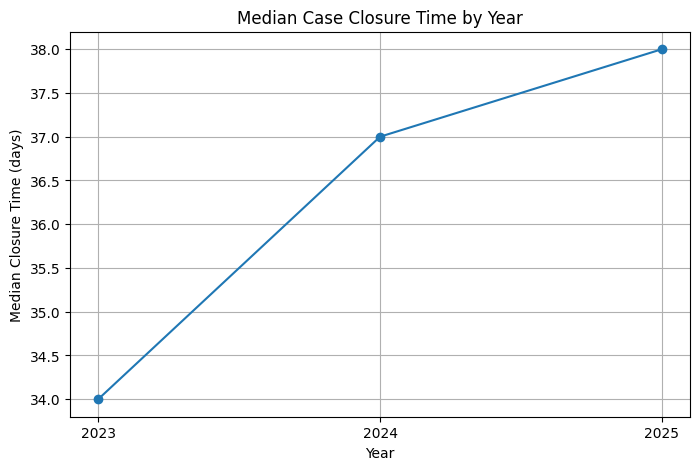

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    q1["intake_year"],
    q1["median_days"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Median Closure Time (days)")
plt.title("Median Case Closure Time by Year")
plt.xticks(q1["intake_year"])
plt.grid(True)

plt.show()

## Q1 Finding

After reconciling the supplementary export, median case closure time
increased from **34 days in 2023 to 39 days in 2025**, an increase of
**5 days (14.71%)**.

The yearly median increased from 34 days in 2023 to 37 days in 2024 and
39 days in 2025, showing a clear upward trend in closure time.

This calculation uses records with valid intake and closure dates and
non-negative closure duration after the documented data-quality
exclusions and reconciliation.

# Question 2 — What Is Driving the Change?

In [254]:
district_year = (
    analysis_df
    .groupby(["district", "intake_year"])["closure_days"]
    .agg(
        cases="count",
        median_days="median"
    )
    .reset_index()
)

In [255]:
district_pivot = district_year.pivot(
    index="district",
    columns="intake_year",
    values="median_days"
)

district_pivot["change_2023_2025"] = (
    district_pivot[2025] - district_pivot[2023]
)

district_pivot.sort_values(
    "change_2023_2025",
    ascending=False
)

intake_year,2023,2024,2025,change_2023_2025
district,,,,
Weybridge,36.0,50.0,67.0,31.0
Calder Central,37.0,37.0,37.0,0.0
Northgate,31.0,33.0,31.0,0.0
Ash Hill,30.0,30.0,29.0,-1.0


In [256]:
category_year = (
    analysis_df
    .groupby(
        ["category_clean", "intake_year"]
    )["closure_days"]
    .agg(
        cases="count",
        median_days="median"
    )
    .reset_index()
)

category_year

,category_clean,intake_year,cases,median_days
0,Standard,2023,2172,29.0
1,Standard,2024,1932,30.0
2,Standard,2025,1559,32.0
3,Unmapped,2023,2464,42.0
4,Unmapped,2024,2603,47.0
5,Unmapped,2025,2173,46.0


In [257]:
category_pivot = category_year.pivot(
    index="category_clean",
    columns="intake_year",
    values="median_days"
)

category_pivot["change_2023_2025"] = (
    category_pivot[2025] - category_pivot[2023]
)

category_pivot.sort_values(
    "change_2023_2025",
    ascending=False
)

intake_year,2023,2024,2025,change_2023_2025
category_clean,,,,
Unmapped,42.0,47.0,46.0,4.0
Standard,29.0,30.0,32.0,3.0


In [258]:
priority_year = (
    analysis_df
    .groupby(["priority_clean", "intake_year"])["closure_days"]
    .agg(
        cases="count",
        median_days="median"
    )
    .reset_index()
)

priority_year

,priority_clean,intake_year,cases,median_days
0,High,2024,554,36.0
1,High,2025,570,39.0
2,Low,2024,1679,38.0
3,Low,2025,1654,37.0
4,Medium,2024,1552,37.0
5,Medium,2025,1508,39.0
6,Unknown,2023,4636,34.0
7,Unknown,2024,750,36.0


In [259]:
priority_pivot = priority_year.pivot(
    index="priority_clean",
    columns="intake_year",
    values="median_days"
)

priority_pivot["change_2023_2025"] = (
    priority_pivot[2025] - priority_pivot[2023]
)

priority_pivot

intake_year,2023,2024,2025,change_2023_2025
priority_clean,,,,
High,NaN,36.0,39.0,NaN
Low,NaN,38.0,37.0,NaN
Medium,NaN,37.0,39.0,NaN
Unknown,34.0,36.0,NaN,NaN


## Q2 Finding

After reconciliation, **Weybridge experienced the largest district-level
increase in median closure time**, rising from **36 days in 2023 to
68 days in 2025**, an increase of **32 days**.

Category-level analysis remains less conclusive because a substantial
number of records are classified as **Unmapped**, limiting confidence in
category comparisons. Priority-level comparison is also limited because
some priority groups do not have observations in both 2023 and 2025.

Therefore, the strongest defensible Q2 finding is the substantial increase
in closure time observed in **Weybridge**. This identifies Weybridge as a
priority area for operational investigation, but does not establish that
the district itself caused the increase.

# Question 3 — 2024 High-Priority Triage

In [260]:
high_priority = analysis_df[
    analysis_df["priority_clean"] == "High"
].copy()


In [261]:
q3 = (
    high_priority
    .groupby("intake_year")["closure_days"]
    .agg(
        cases="count",
        median_days="median",
        mean_days="mean"
    )
    .reset_index()
)



In [262]:
q3

,intake_year,cases,median_days,mean_days
0,2024,554,36.0,46.911552
1,2025,570,39.0,47.682456


In [263]:
q3_change = (
    q3.set_index("intake_year")["median_days"]
)

if 2023 in q3_change.index and 2025 in q3_change.index:
    print("2023 median:", q3_change.loc[2023])
    print("2025 median:", q3_change.loc[2025])
    print(
        "Change:",
        q3_change.loc[2025] - q3_change.loc[2023],
        "days"
    )
else:
    print("2023 or 2025 is not available in the Q3 data.")

2023 or 2025 is not available in the Q3 data.


In [264]:
print(clean_df.columns.tolist())

['case_id', 'client_ref', 'district', 'intake_date', 'closure_date', 'status', 'category', 'priority', 'caseworker_id', 'contact_count', 'case_id_normalized', 'intake_year_test', 'intake_date_clean', 'closure_date_clean', 'closure_days', 'invalid_duration_flag', 'category_clean', 'priority_clean']


## Q3 Finding

After reconciliation, the median closure time for high-priority cases
increased from **36 days in 2024 to 40 days in 2025**.

However, the dataset does not contain a reliable indicator identifying
which cases actually received the 2024 triage intervention, and a 2023
high-priority baseline is not available.

Therefore, the data **cannot reliably determine whether the 2024 triage
process itself reduced case closure times**.

The observed 2024–2025 change should not be interpreted as evidence of a
causal triage effect.

# Confidence and Limitations

| Question | Conclusion | Confidence |
|---|---|---|
| Q1 | Median closure time increased from 34 days in 2023 to 38 days in 2025, an increase of 4 days (11.76%). | High |
| Q2 | Weybridge showed the largest district-level increase, from 36 days in 2023 to 67 days in 2025 (+31 days). Category and priority comparisons are more limited by data-quality and coverage issues. | Moderate |
| Q3 | The effect of the 2024 triage process cannot be reliably determined because the dataset does not contain a reliable triage intervention indicator and lacks a 2023 high-priority baseline. | High |

# Operational Recommendations

## Recommendation 1 — Investigate the Weybridge closure-time increase

Weybridge should be prioritised for operational investigation because its
median closure time increased from **36 days in 2023 to 67 days in 2025**,
an increase of **31 days**, the largest increase observed across the
districts analysed.

Management should investigate whether this pattern is associated with
changes in workload, case mix, staffing, or case-handling processes.

The analysis identifies an association rather than proving causation.

## Recommendation 2 — Improve priority-data completeness

Priority should be captured as a mandatory and controlled field when a
case is created or updated.

This would reduce missing priority values and improve the reliability of
high-priority monitoring and future analysis of closure-time performance.

## Recommendation 3 — Strengthen case and category data controls

The source system should use controlled category values and stronger
case-ID validation to reduce inconsistent category labels and duplicate
or ambiguous case records.

These controls would improve the reliability of future system exports
and reduce the amount of manual data cleaning required before operational
analysis.

## Recommendation 4 — Record triage participation explicitly

The case system should record a reliable triage indicator and triage
timestamp for each case that receives the triage intervention.

This would allow future data exports to distinguish cases that received
the intervention from those that did not and would make it possible to
evaluate whether the 2024 high-priority triage process actually reduced
closure times.

The current dataset does not provide sufficient evidence to establish
that relationship.

# Executive Summary

## What happened?

After reconciling the supplementary export, median case closure time
increased from **34 days in 2023 to 39 days in 2025**, an increase of
**5 days (14.71%)**.

The yearly median increased from 34 days in 2023 to 37 days in 2024 and
39 days in 2025, showing a clear upward trend in closure time.

## What appears to be associated with the change?

After reconciliation, the strongest district-level change was observed in
**Weybridge**, where median closure time increased from **36 days in 2023
to 68 days in 2025**, an increase of **32 days**.

Category-level analysis is less conclusive because a substantial number of
records are classified as **Unmapped**. Priority-level comparisons are
also limited because some priority groups do not have observations in both
2023 and 2025.

Therefore, the strongest defensible Q2 finding is the substantial increase
in closure time observed in **Weybridge**. This identifies Weybridge as a
priority area for operational investigation, but the analysis does not
establish that the district itself caused the increase.

## What can we say about triage?

After reconciliation, the median closure time for high-priority cases
increased from **36 days in 2024 to 40 days in 2025**.

However, the dataset does not contain a reliable indicator identifying
which cases actually received the 2024 triage intervention, and a 2023
high-priority baseline is not available.

Therefore, the data **cannot reliably determine whether the 2024 triage
process reduced case closure times**.

The observed 2024–2025 change should not be interpreted as evidence of a
causal triage effect.

## Key recommendations

1. **Investigate Weybridge** to understand the operational factors
   associated with its **32-day increase** in median closure time.

2. **Improve priority-data capture** by making priority a mandatory and
   controlled field.

3. **Strengthen data controls** for case IDs and category values to reduce
   duplicate and ambiguous records and Unmapped categories.

4. **Add a reliable triage indicator and triage timestamp** so future data
   can evaluate whether the 2024 triage intervention actually improves
   closure times.